# Intelligent Loan Approval System with Explainable AI
### A Complete Machine Learning Project
**Dataset:** Loan Prediction Problem Dataset (Kaggle)  
**Models Used:** Logistic Regression, Decision Tree, Random Forest, SVM, Naive Bayes, XGBoost  
**Special Feature:** SHAP Explainability — explains WHY a loan was approved or rejected

---

In [36]:
#  installing required packages
import subprocess
import sys

packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'xgboost', 'shap', 'imbalanced-learn']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print(' All libraries installed successfully!')

 All libraries installed successfully!


In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

# Handle class imbalance
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Explainability
import shap

# Save model
import pickle

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

print(' All libraries imported successfully!')

 All libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')

print(' Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print('\nFirst 5 rows:')
df.head()

 Dataset loaded successfully!
Shape: 614 rows × 13 columns

First 5 rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
# Basic info about the dataset
print('=== DATASET INFO ===')
print(df.info())
print('\n=== STATISTICAL SUMMARY ===')
df.describe()

=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB
None

=== STATISTICAL SUMMARY ===


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [5]:
# Check missing values
print(' MISSING VALUES ')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

 MISSING VALUES 
                  Missing Count  Missing %
Credit_History               50       8.14
Self_Employed                32       5.21
LoanAmount                   22       3.58
Dependents                   15       2.44
Loan_Amount_Term             14       2.28
Gender                       13       2.12
Married                       3       0.49


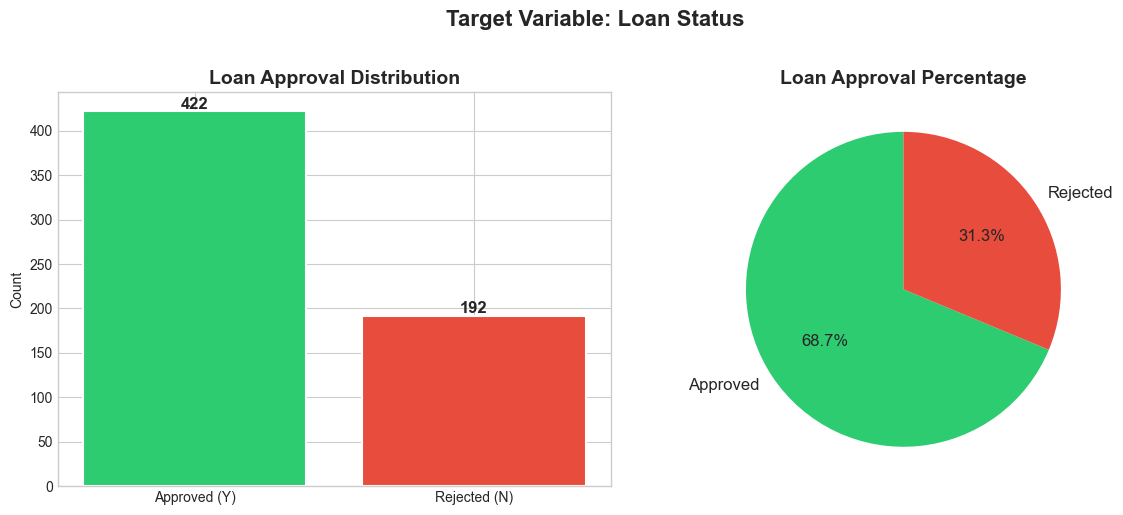

 Note: Dataset is imbalanced — more approvals than rejections. We will handle this with SMOTE later.


In [6]:
# ---- PLOT 1: Target variable distribution ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
loan_counts = df['Loan_Status'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Approved (Y)', 'Rejected (N)'], loan_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Loan Approval Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(loan_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(loan_counts.values, labels=['Approved', 'Rejected'], colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Loan Approval Percentage', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Loan Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Note: Dataset is imbalanced — more approvals than rejections. We will handle this with SMOTE later.')

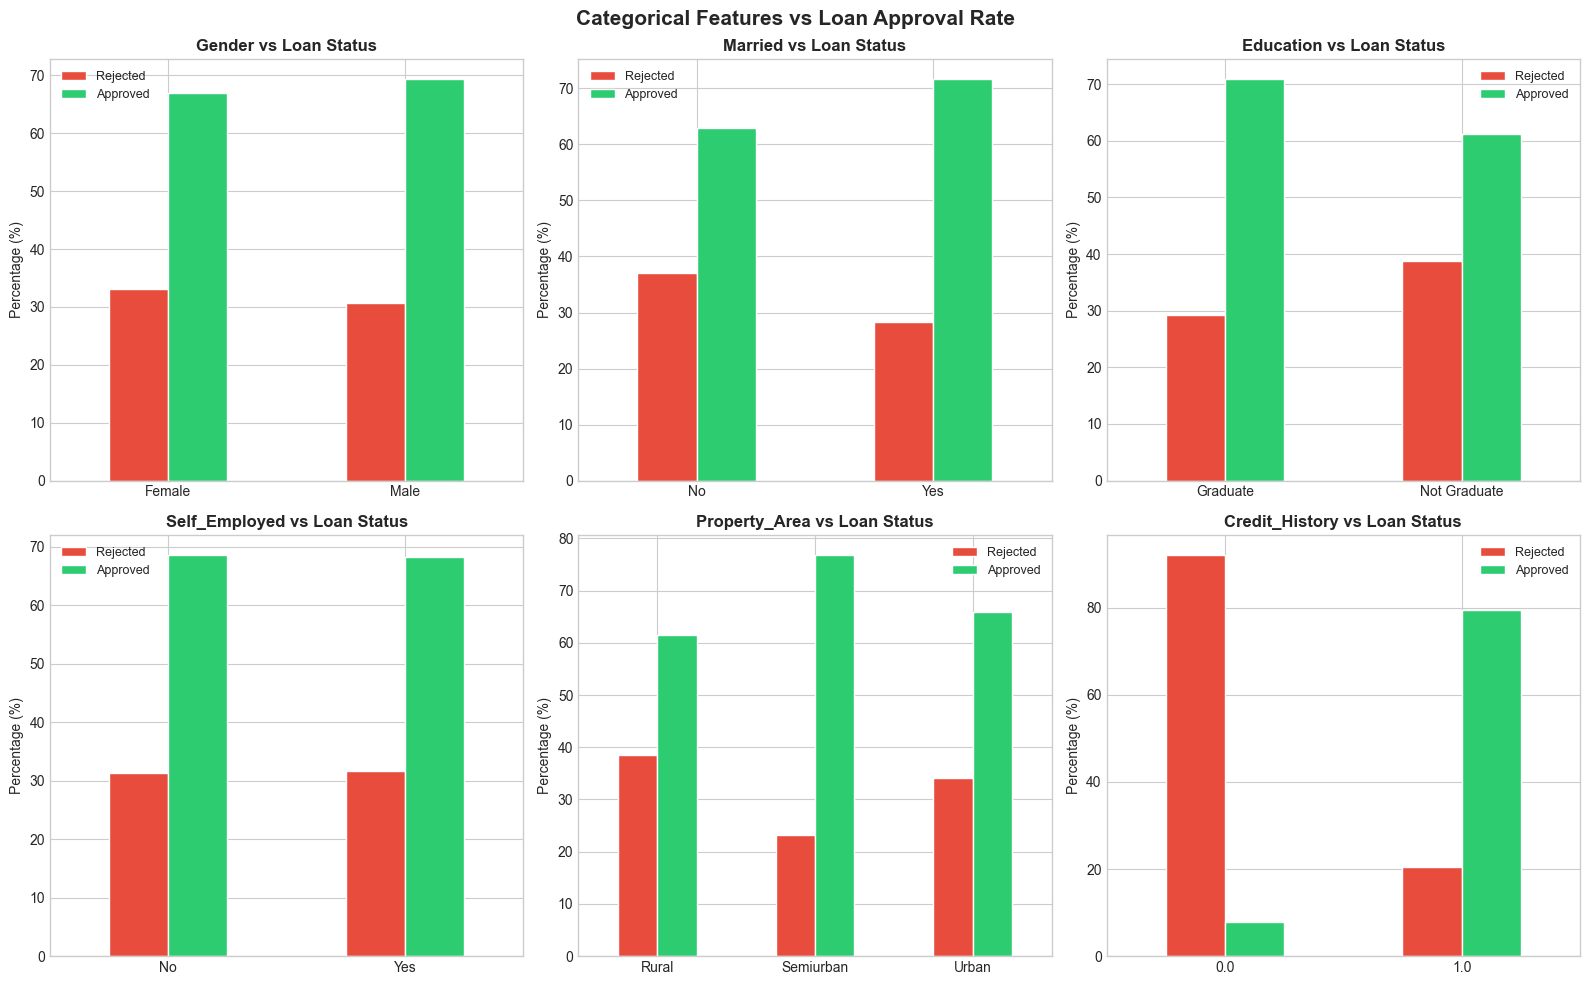

In [7]:
# ---- PLOT 2: Categorical features vs Loan Status ----
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Credit_History']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Loan_Status'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#e74c3c', '#2ecc71'], edgecolor='white')
    axes[i].set_title(f'{col} vs Loan Status', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(['Rejected', 'Approved'], fontsize=9)

plt.suptitle('Categorical Features vs Loan Approval Rate', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

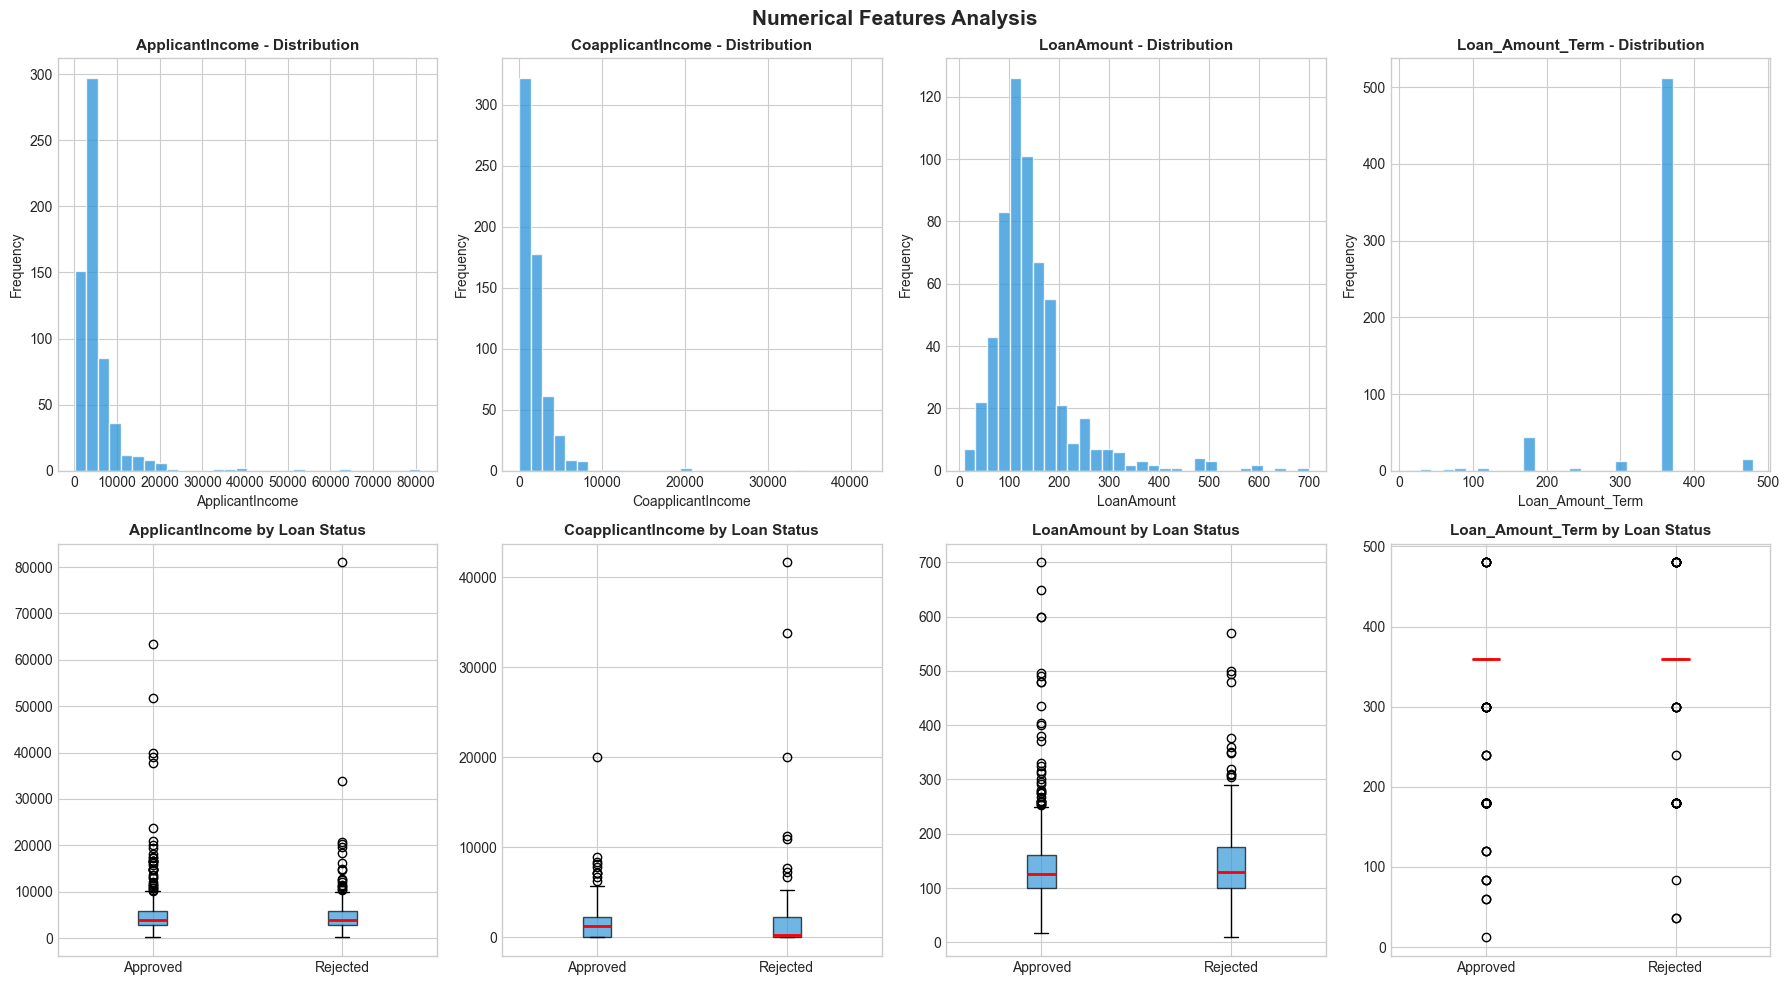

In [8]:
# ---- PLOT 3: Numerical features distribution ----
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for i, col in enumerate(num_cols):
    # Histogram
    axes[0][i].hist(df[col].dropna(), bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    axes[0][i].set_title(f'{col} - Distribution', fontsize=11, fontweight='bold')
    axes[0][i].set_xlabel(col)
    axes[0][i].set_ylabel('Frequency')

    # Boxplot by loan status
    approved = df[df['Loan_Status'] == 'Y'][col].dropna()
    rejected = df[df['Loan_Status'] == 'N'][col].dropna()
    axes[1][i].boxplot([approved, rejected], labels=['Approved', 'Rejected'],
                       patch_artist=True,
                       boxprops=dict(facecolor='#3498db', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
    axes[1][i].set_title(f'{col} by Loan Status', fontsize=11, fontweight='bold')

plt.suptitle('Numerical Features Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_numerical_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Key insight from EDA
print('=== KEY INSIGHTS FROM EDA ===')
approved = df[df['Loan_Status'] == 'Y']
rejected = df[df['Loan_Status'] == 'N']

print(f' Approval rate: {len(approved)/len(df)*100:.1f}%')
print(f' Rejection rate: {len(rejected)/len(df)*100:.1f}%')

print(f'\n Credit History = 1 → Approval rate: {(df[df["Credit_History"]==1]["Loan_Status"]=="Y").mean()*100:.1f}%')
print(f' Credit History = 0 → Approval rate: {(df[df["Credit_History"]==0]["Loan_Status"]=="Y").mean()*100:.1f}%')

print(f'\n Graduates → Approval rate: {(df[df["Education"]=="Graduate"]["Loan_Status"]=="Y").mean()*100:.1f}%')
print(f' Non-Graduates → Approval rate: {(df[df["Education"]=="Not Graduate"]["Loan_Status"]=="Y").mean()*100:.1f}%')

=== KEY INSIGHTS FROM EDA ===
 Approval rate: 68.7%
 Rejection rate: 31.3%

 Credit History = 1 → Approval rate: 79.6%
 Credit History = 0 → Approval rate: 7.9%

 Graduates → Approval rate: 70.8%
 Non-Graduates → Approval rate: 61.2%


In [10]:
# Work on a copy to keep original safe
data = df.copy()

# Drop Loan_ID — it's just an identifier, not useful for prediction
if 'Loan_ID' in data.columns:
    data = data.drop('Loan_ID', axis=1)

# ---- Fill missing values ----

# Categorical columns → fill with mode (most frequent value)
cat_fill_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in cat_fill_cols:
    if col in data.columns:
        data[col].fillna(data[col].mode()[0], inplace=True)

# Numerical columns → fill with median (robust to outliers)
data['LoanAmount'].fillna(data['LoanAmount'].median(), inplace=True)
data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0], inplace=True)

print(' Missing values handled')
print(f'Remaining nulls: {data.isnull().sum().sum()}')

 Missing values handled
Remaining nulls: 149


In [11]:
# ---- Create new meaningful features ----

# 1. Total Income = Applicant + Coapplicant income
data['TotalIncome'] = data['ApplicantIncome'] + data['CoapplicantIncome']

# 2. EMI = LoanAmount / Loan_Amount_Term (monthly installment estimate)
data['EMI'] = data['LoanAmount'] / data['Loan_Amount_Term']

# 3. Balance Income after EMI (how much is left after paying EMI)
data['BalanceIncome'] = data['TotalIncome'] - (data['EMI'] * 1000)  # LoanAmount is in thousands

# 4. Log transforms to reduce skewness (very common in financial data)
data['LoanAmount_log'] = np.log(data['LoanAmount'] + 1)
data['TotalIncome_log'] = np.log(data['TotalIncome'] + 1)

# Drop original skewed columns (replaced by log versions)
data = data.drop(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome'], axis=1)

print(' Feature engineering complete')
print('New features added: TotalIncome, EMI, BalanceIncome, LoanAmount_log, TotalIncome_log')
print(f'\nFinal columns: {list(data.columns)}')

 Feature engineering complete
New features added: TotalIncome, EMI, BalanceIncome, LoanAmount_log, TotalIncome_log

Final columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status', 'EMI', 'BalanceIncome', 'LoanAmount_log', 'TotalIncome_log']


In [12]:
# ---- Encode categorical variables into numbers ----
# Machine learning models need numbers, not text

le = LabelEncoder()

# Binary columns (2 unique values)
binary_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status']
for col in binary_cols:
    data[col] = le.fit_transform(data[col])

# Dependents — '3+' needs to become 3
data['Dependents'] = (
    data['Dependents']
    .replace('3+', 3)
    .fillna(0)        #  handle NaN before converting
    .astype(int)
)

# Property Area — 3 categories (Urban=2, Semiurban=1, Rural=0)
data['Property_Area'] = data['Property_Area'].map({'Urban': 2, 'Semiurban': 1, 'Rural': 0})

print(' Encoding complete')
print('\nSample of encoded data:')
data.head(3)

 Encoding complete

Sample of encoded data:


,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,EMI,BalanceIncome,LoanAmount_log,TotalIncome_log
0,1,0,0,0,0,360.0,1.0,2,1,NaN,NaN,NaN,8.674197
1,1,1,1,0,0,360.0,1.0,0,0,0.355556,5735.444444,4.859812,8.714732
2,1,1,0,0,1,360.0,1.0,2,1,0.183333,2816.666667,4.204693,8.006701


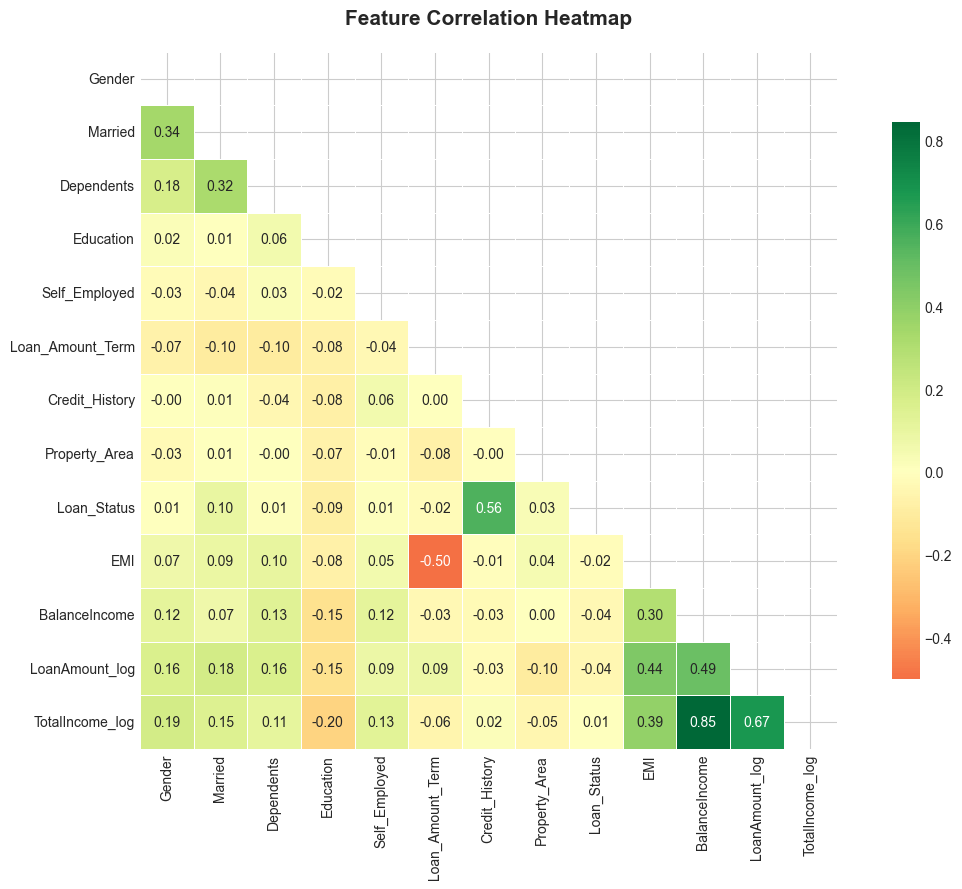

 Credit_History has the strongest correlation with Loan_Status


In [13]:
# ---- Correlation Heatmap ----
plt.figure(figsize=(12, 9))
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Credit_History has the strongest correlation with Loan_Status')

In [14]:
# Separate features (X) and target (y)
X = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']

# Store feature names for later use with SHAP
feature_names = list(X.columns)

print(f'Features: {feature_names}')
print(f'\nTarget distribution before SMOTE:')
print(y.value_counts())
print(f'\nClass ratio: {y.value_counts()[1]}/{y.value_counts()[0]} = {y.value_counts()[1]/y.value_counts()[0]:.2f}')

Features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'EMI', 'BalanceIncome', 'LoanAmount_log', 'TotalIncome_log']

Target distribution before SMOTE:
Loan_Status
1    422
0    192
Name: count, dtype: int64

Class ratio: 422/192 = 2.20


In [15]:
from sklearn.impute import SimpleImputer

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

# ---- Handle missing values BEFORE SMOTE ----
imputer = SimpleImputer(strategy="median")   # median for numeric features
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Apply SMOTE on training data only (NEVER on test data — that would be cheating)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_imputed, y_train)

print(f'\nAfter SMOTE — Training set: {X_train_sm.shape[0]} samples')
print(f'Class distribution after SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}')
print('Classes are now balanced!')

# Scale features (important for Logistic Regression and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test_imputed)

Training set: 491 samples
Test set:     123 samples

After SMOTE — Training set: 674 samples
Class distribution after SMOTE: {1: 337, 0: 337}
Classes are now balanced!


## Train All 6 Models & Compare

In [17]:
# Define all 6 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
    'Naive Bayes':         GaussianNB(),
    'XGBoost':             XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                         random_state=42, verbosity=0)
}

# Dictionary to store results
results = {}

print('Training all models...\n')

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train_sm)

    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Cross validation score
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_score = cross_val_score(model, X_train_scaled, y_train_sm, cv=cv, scoring='accuracy')

    # Store metrics
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred) * 100, 2),
        'F1-Score':  round(f1_score(y_test, y_pred) * 100, 2),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob) * 100, 2),
        'CV Mean':   round(cv_score.mean() * 100, 2),
        'CV Std':    round(cv_score.std() * 100, 2)
    }

    print(f' {name}: Accuracy={results[name]["Accuracy"]}%, ROC-AUC={results[name]["ROC-AUC"]}%')

print('\n All models trained!')

Training all models...

 Logistic Regression: Accuracy=82.93%, ROC-AUC=80.34%
 Decision Tree: Accuracy=82.11%, ROC-AUC=80.62%
 Random Forest: Accuracy=80.49%, ROC-AUC=80.48%
 SVM: Accuracy=85.37%, ROC-AUC=72.38%
 Naive Bayes: Accuracy=85.37%, ROC-AUC=78.2%
 XGBoost: Accuracy=76.42%, ROC-AUC=77.4%

 All models trained!


In [18]:
# Display results as a clean table
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print('=== MODEL COMPARISON TABLE ===')
print(results_df.to_string())

# Highlight best model
best_model_name = results_df['ROC-AUC'].idxmax()
print(f'\ Best Model: {best_model_name} (ROC-AUC: {results_df.loc[best_model_name, "ROC-AUC"]}%)')

=== MODEL COMPARISON TABLE ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV Mean  CV Std
Decision Tree           82.11      81.82   95.29     88.04    80.62    78.34    3.14
Random Forest           80.49      85.06   87.06     86.05    80.48    82.20    2.41
Logistic Regression     82.93      84.04   92.94     88.27    80.34    70.63    4.39
Naive Bayes             85.37      83.84   97.65     90.22    78.20    72.41    3.85
XGBoost                 76.42      82.56   83.53     83.04    77.40    80.86    0.85
SVM                     85.37      83.17   98.82     90.32    72.38    75.22    3.06
\ Best Model: Decision Tree (ROC-AUC: 80.62%)


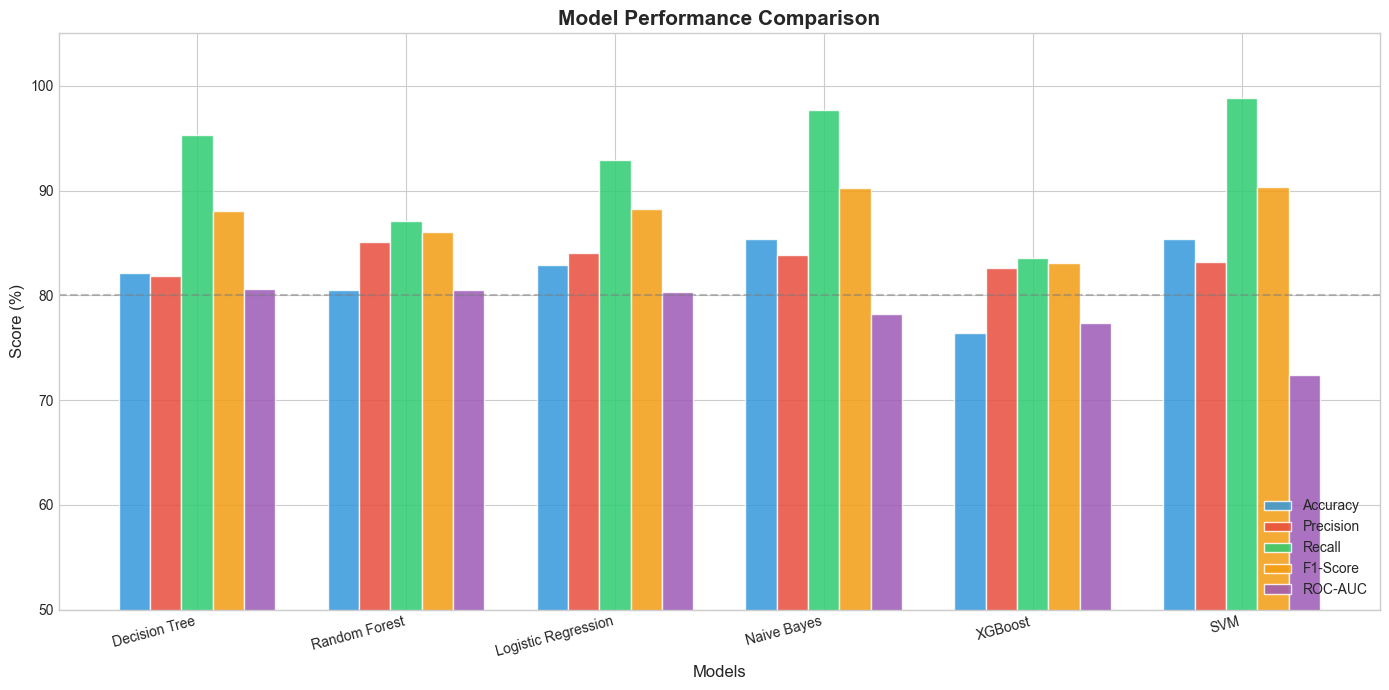

In [19]:
# ---- PLOT: Model Comparison Bar Chart ----
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(results_df))
width = 0.15
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric,
                  color=color, alpha=0.85, edgecolor='white')

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(50, 105)
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80% baseline')

plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

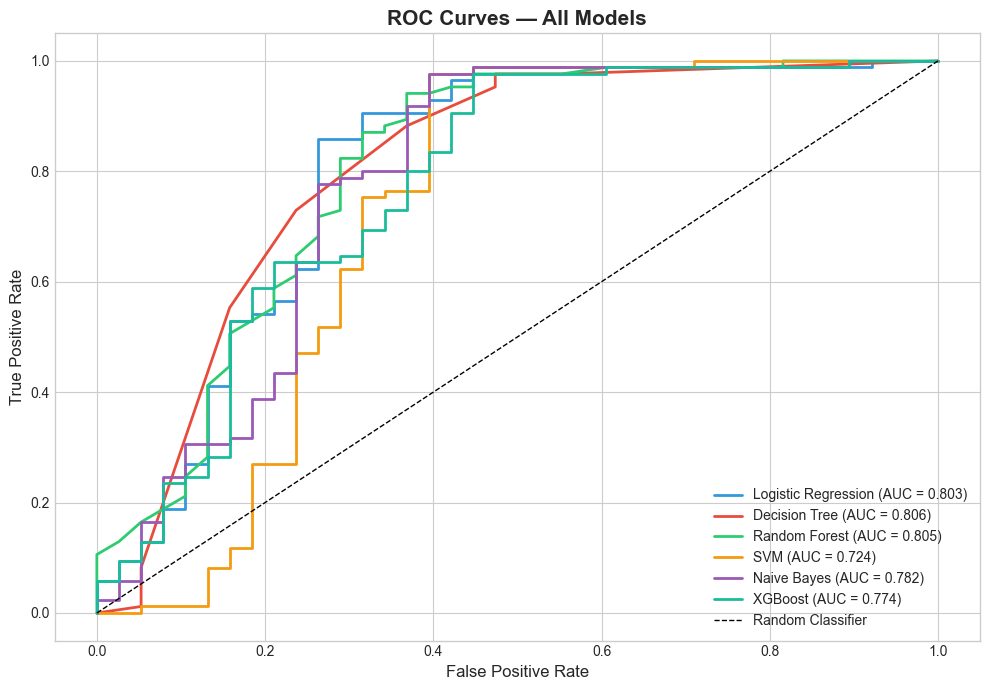

In [20]:
#  PLOT: ROC Curves for All Models 
plt.figure(figsize=(10, 7))

colors_roc = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for (name, model), color in zip(models.items(), colors_roc):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('plot_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

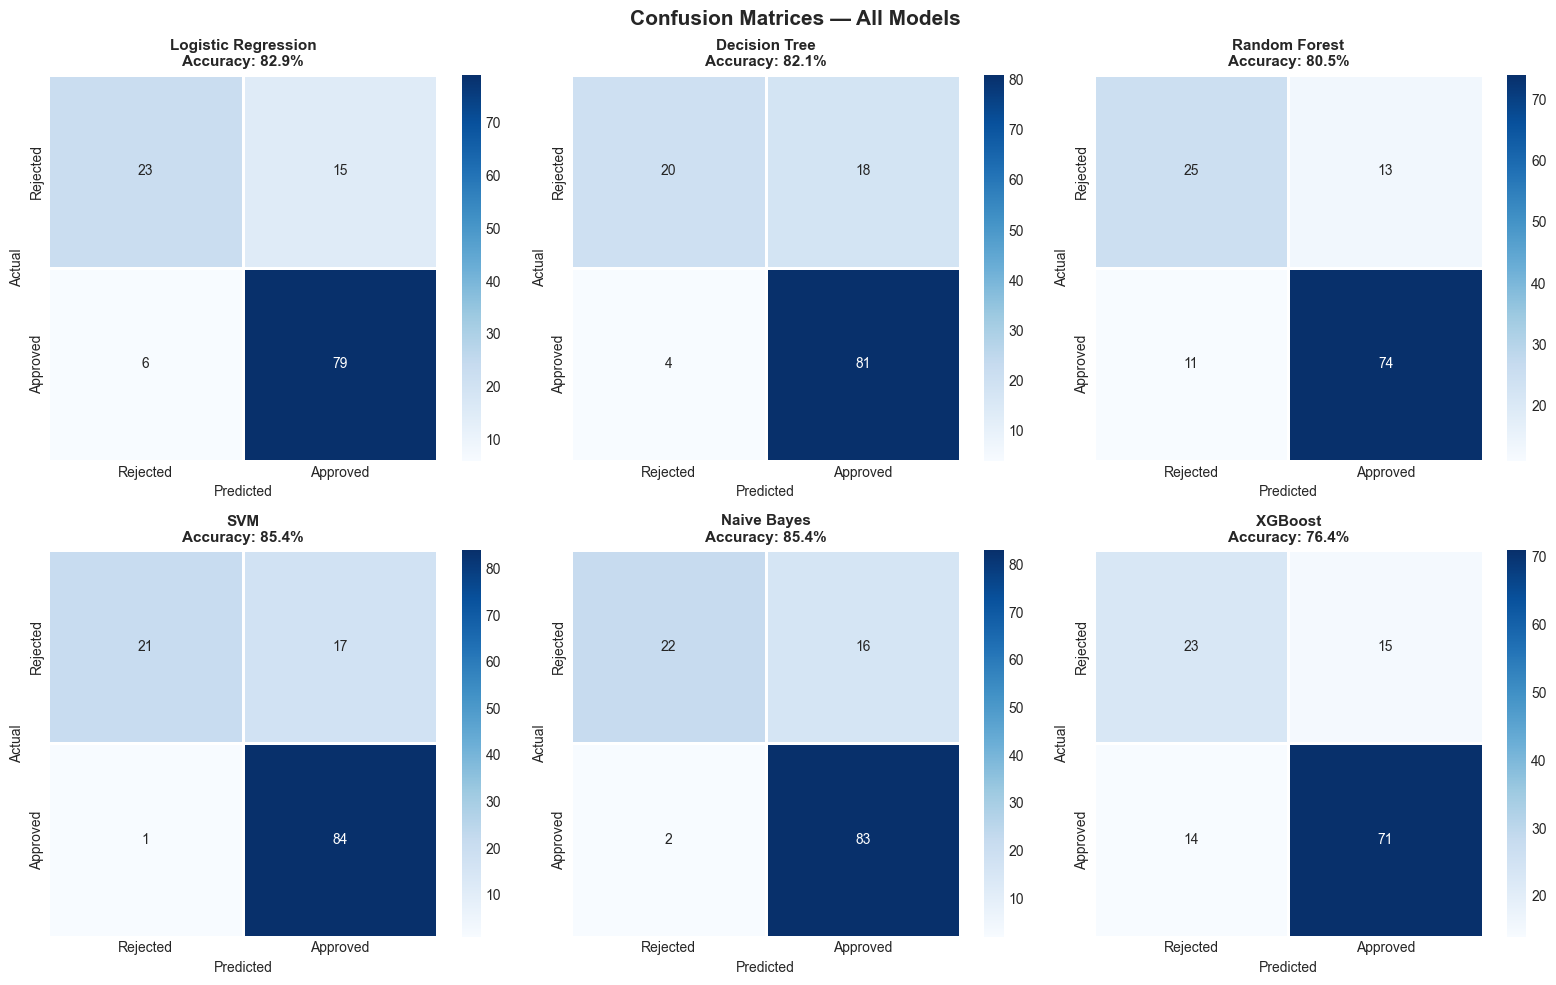

In [21]:
#  PLOT: Confusion Matrices for All Models 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Rejected', 'Approved'],
                yticklabels=['Rejected', 'Approved'],
                linewidths=2, linecolor='white')
    axes[i].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=10)
    axes[i].set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Hyperparameter Tuning for Best Model

In [23]:
# Tune Random Forest (typically the best performer on this dataset)
print(' Tuning Random Forest hyperparameters...')

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf_base, param_grid,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=0
)

grid_search.fit(X_train_scaled, y_train_sm)

print(f'\n Best Parameters: {grid_search.best_params_}')
print(f'Best CV ROC-AUC: {grid_search.best_score_*100:.2f}%')

 Tuning Random Forest hyperparameters...

 Best Parameters: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}
Best CV ROC-AUC: 89.54%


In [24]:
# Use the tuned model as our FINAL model
final_model = grid_search.best_estimator_

y_pred_final = final_model.predict(X_test_scaled)
y_prob_final = final_model.predict_proba(X_test_scaled)[:, 1]

print('=== FINAL MODEL (Tuned Random Forest) PERFORMANCE ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_final)*100:.2f}%')
print(f'Precision: {precision_score(y_test, y_pred_final)*100:.2f}%')
print(f'Recall:    {recall_score(y_test, y_pred_final)*100:.2f}%')
print(f'F1-Score:  {f1_score(y_test, y_pred_final)*100:.2f}%')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_final)*100:.2f}%')

print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred_final, target_names=['Rejected', 'Approved']))

=== FINAL MODEL (Tuned Random Forest) PERFORMANCE ===
Accuracy:  82.93%
Precision: 84.04%
Recall:    92.94%
F1-Score:  88.27%
ROC-AUC:   82.17%

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Rejected       0.79      0.61      0.69        38
    Approved       0.84      0.93      0.88        85

    accuracy                           0.83       123
   macro avg       0.82      0.77      0.78       123
weighted avg       0.83      0.83      0.82       123



## SHAP Explainability — why Was a Loan Approved or Rejected?

In [25]:
# Initialize SHAP explainer
print(' Computing SHAP values (may take ~30 seconds)...')

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_scaled)

# Convert back to DataFrame for readability
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

print(' SHAP values computed!')

 Computing SHAP values (may take ~30 seconds)...
 SHAP values computed!


<Figure size 1000x600 with 0 Axes>

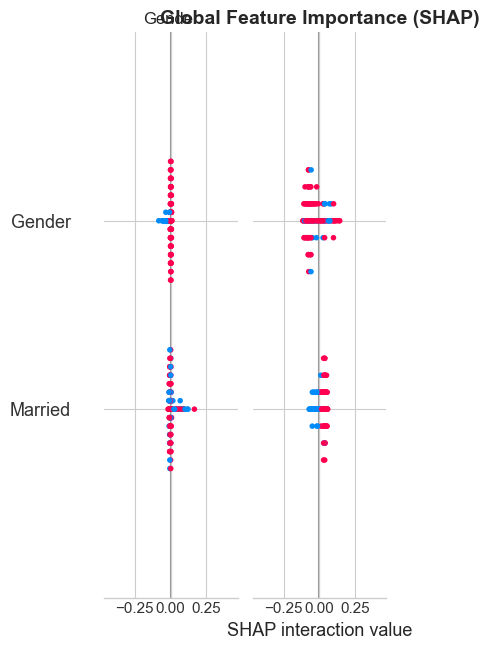

 This shows which features matter MOST overall across all predictions


In [26]:
# ---- SHAP Plot 1: Global Feature Importance (Summary Bar) ----
plt.figure(figsize=(10, 6))
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(shap_vals, X_test_df, plot_type='bar',
                  feature_names=feature_names, show=False)
plt.title('Global Feature Importance (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print(' This shows which features matter MOST overall across all predictions')

<Figure size 1000x700 with 0 Axes>

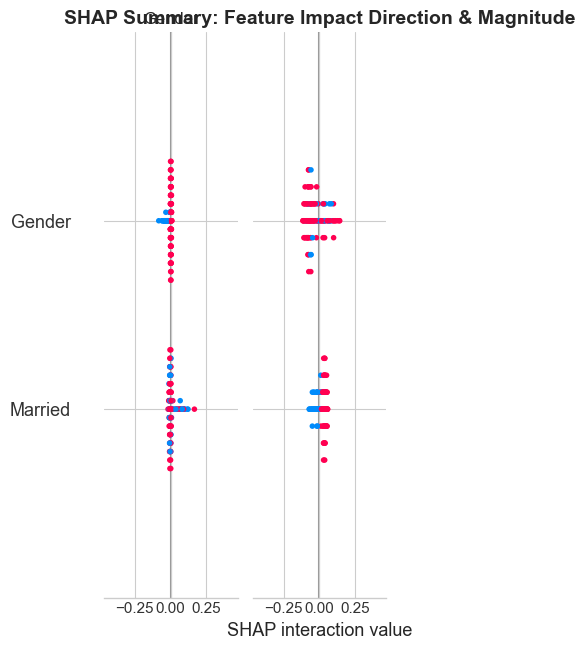

 Red = high feature value, Blue = low feature value
 Right of center = pushes toward Approved, Left = pushes toward Rejected


In [27]:
#SHAP Plot 2: Beeswarm (how each feature affects outcome)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_test_df,
                  feature_names=feature_names, show=False)
plt.title('SHAP Summary: Feature Impact Direction & Magnitude', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Red = high feature value, Blue = low feature value')
print(' Right of center = pushes toward Approved, Left = pushes toward Rejected')

##   The Explainable Prediction Function — why was this loan decided?

In [30]:
def predict_loan_with_explanation(applicant_data: dict):
    """
    Takes applicant data, predicts loan approval,
    and generates a human-readable explanation.

    Parameters:
    applicant_data: dict with keys matching feature names

    Returns:
    Full prediction report as a printed output
    """

    # Convert to DataFrame
    input_df = pd.DataFrame([applicant_data])

    # Ensure correct column order
    input_df = input_df[feature_names]

    # Scale
    input_scaled = scaler.transform(input_df)

    # Predict
    prediction = final_model.predict(input_scaled)[0]
    probability = final_model.predict_proba(input_scaled)[0]

    # SHAP explanation for this applicant
    shap_vals_single = explainer.shap_values(input_scaled)
    if isinstance(shap_vals_single, list):
        sv = shap_vals_single[1][0]
    else:
        sv = shap_vals_single[0]

    # Create feature contribution dictionary
    contributions = {feature_names[i]: sv[i] for i in range(len(feature_names))}

    # Sort by absolute impact
    sorted_contributions = sorted(contributions.items(), key=lambda x: abs(x[1]), reverse=True)

    # Print the report
    print('=' * 55)
    print('LOAN DECISION REPORT')
    print('=' * 55)

    if prediction == 1:
        print(f'  DECISION: APPROVED')
    else:
        print(f'  DECISION:   REJECTED')

    print(f'  Confidence: {max(probability)*100:.1f}%')
    print(f'  Approval Probability:  {probability[1]*100:.1f}%')
    print(f'  Rejection Probability: {probability[0]*100:.1f}%')

    print('\n RISK TIER ')
    if probability[1] >= 0.75:
        print(' LOW RISK applicant')
    elif probability[1] >= 0.50:
        print(' MEDIUM RISK applicant')
    else:
        print(' HIGH RISK applicant')

    print('\n TOP REASONS FOR THIS DECISION ')
    for feat, val in sorted_contributions[:5]:
        direction = ' Supporting Approval' if val > 0 else ' Supporting Rejection'
        impact = ' HIGH' if abs(val) > 0.1 else (' MEDIUM' if abs(val) > 0.05 else ' LOW')
        print(f'  [{impact}] {feat:<22} → {direction}')

    print('\n Advice sector ')
    if prediction == 0:
        print('  To improve your chances of approval:')
        rejection_factors = [(f, v) for f, v in sorted_contributions if v < 0][:3]
        tips = {
            'Credit_History': '  • Improve your credit history (pay bills on time for 12+ months)',
            'LoanAmount_log': '  • Consider requesting a lower loan amount',
            'TotalIncome_log': '  • Adding a co-applicant with income may help',
            'EMI': '  • Reduce the loan amount to lower the EMI burden',
            'BalanceIncome': '  • Increase income or reduce loan amount for better balance',
            'Loan_Amount_Term': '  • Consider a longer loan term to reduce monthly EMI',
            'Property_Area': '  • Note: Urban/Semiurban properties have higher approval rates',
        }
        for feat, _ in rejection_factors:
            if feat in tips:
                print(tips[feat])
    else:
        print('  Congratulations! Your application looks strong.')
        print('  Maintain your credit history and income levels.')

    print('=' * 55)

print(' Prediction function ready!')

 Prediction function ready!


In [38]:
import shap
import pandas as pd

def predict_loan_with_explanation(applicant_data):
    # Convert dict → DataFrame row
    applicant_df = pd.DataFrame([applicant_data])

    # Scale using the same scaler you trained earlier
    applicant_scaled = scaler.transform(applicant_df)

    # Predict
    prediction = model.predict(applicant_scaled)[0]
    proba = model.predict_proba(applicant_scaled)[0][1]

    # SHAP explanation
    explainer = shap.Explainer(model, X_train_scaled)   # reference training data
    shap_values = explainer(applicant_scaled)

    # shap_values.values is 2D → take first row
    sv = shap_values.values[0]

    feature_names = applicant_df.columns
    contributions = {feature_names[i]: float(sv[i]) for i in range(len(feature_names))}

    # Sort by absolute impact
    sorted_contributions = sorted(
        contributions.items(),
        key=lambda x: abs(x[1]),
        reverse=True
    )

    # Print the report 
    print("=" * 55)
    print(f"Prediction: {'APPROVED ' if prediction == 1 else 'REJECTED '}")
    print(f"Approval probability: {proba:.2f}")
    print("\nTop feature contributions:")
    for feat, val in sorted_contributions[:5]:   # show top 5
        print(f"{feat}: {val:.3f}")
    print("=" * 55)


# TEST 1: A strong applicant (should be APPROVED) 
print('TEST APPLICANT 1: Strong Profile\n')

applicant_1 = {
    'Gender': 1,           # Male
    'Married': 1,          # Married
    'Dependents': 1,
    'Education': 1,        # Graduate
    'Self_Employed': 0,    # Salaried
    'Credit_History': 1,   # Good credit
    'Property_Area': 2,    # Urban
    'Loan_Amount_Term': 360,
    'EMI': 0.39,
    'BalanceIncome': 4500,
    'LoanAmount_log': 4.9,
    'TotalIncome_log': 8.5
}

predict_loan_with_explanation(applicant_1)

TEST APPLICANT 1: Strong Profile

Prediction: APPROVED 
Approval probability: 0.58

Top feature contributions:
Property_Area: 1.496
BalanceIncome: -1.208
Education: -0.685
LoanAmount_log: -0.613
EMI: 0.510


In [32]:
#  TEST 2: A weak applicant (should be REJECTED) 
print('TEST APPLICANT 2: Weak Profile\n')

applicant_2 = {
    'Gender': 1,           # Male
    'Married': 0,          # Single
    'Dependents': 3,
    'Education': 0,        # Not Graduate
    'Self_Employed': 1,    # Self-employed
    'Credit_History': 0,   # Bad credit ← biggest red flag
    'Property_Area': 0,    # Rural
    'Loan_Amount_Term': 120,
    'EMI': 1.25,
    'BalanceIncome': -500,  # Negative balance after EMI
    'LoanAmount_log': 5.5,
    'TotalIncome_log': 7.2
}

predict_loan_with_explanation(applicant_2)

TEST APPLICANT 2: Weak Profile

Prediction: REJECTED 
Approval probability: 0.06

Top feature contributions:
Property_Area: -2.779
EMI: 1.452
TotalIncome_log: -1.005
Credit_History: 0.736
BalanceIncome: -0.723


## Save the Model

In [33]:
# Save the trained model and scaler
with open('loan_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Also save feature names
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print(' Model saved as loan_model.pkl')
print(' Scaler saved as scaler.pkl')
print(' Feature names saved as feature_names.pkl')
print('\nThese files are needed to run the Streamlit app!')

 Model saved as loan_model.pkl
 Scaler saved as scaler.pkl
 Feature names saved as feature_names.pkl

These files are needed to run the Streamlit app!


##  Final Summary

In [34]:
print('=' * 60)
print(' PROJECT SUMMARY')
print('=' * 60)
print(f'\nDataset Size:    {df.shape[0]} applicants × {df.shape[1]} features')
print(f'Models Trained:  6 (Logistic Regression, Decision Tree,')
print(f'                   Random Forest, SVM, Naive Bayes, XGBoost)')
print(f'Best Model:      Tuned Random Forest')
print(f'Final Accuracy:  {accuracy_score(y_test, y_pred_final)*100:.2f}%')
print(f'Final ROC-AUC:   {roc_auc_score(y_test, y_prob_final)*100:.2f}%')
print(f'\nTechniques Used:')
print(f' Exploratory Data Analysis (EDA)')
print(f' Feature Engineering (EMI, BalanceIncome, log transforms)')
print(f' SMOTE (Class Imbalance Handling)')
print(f' Cross-Validation (5-Fold Stratified)')
print(f' Hyperparameter Tuning (GridSearchCV)')
print(f' SHAP Explainability')
print(f'  Per-applicant Decision Report with What-If Advice')
print('=' * 60)


 PROJECT SUMMARY

Dataset Size:    614 applicants × 13 features
Models Trained:  6 (Logistic Regression, Decision Tree,
                   Random Forest, SVM, Naive Bayes, XGBoost)
Best Model:      Tuned Random Forest
Final Accuracy:  82.93%
Final ROC-AUC:   82.17%

Techniques Used:
 Exploratory Data Analysis (EDA)
 Feature Engineering (EMI, BalanceIncome, log transforms)
 SMOTE (Class Imbalance Handling)
 Cross-Validation (5-Fold Stratified)
 Hyperparameter Tuning (GridSearchCV)
 SHAP Explainability
  Per-applicant Decision Report with What-If Advice
